# Plan view composites
This notebook plots spatial composites for each ensemble set. Select the ensemble set, and pick the times to composite across. Several cells are commented out, but are useful if you only want to look at composites of ensemble members that produced TCs...

Otherwise, we are compositing across an absolute time, which is the time at which TC genesis occurred in nature. This can be adjusted, but should be the same length as the init_times list, or the number of ensemble members.

### One important note...
The final composite is window is limited to that of the user's selection. Make sure you know the location of the wave whether Paulette or Rene, and base the window zoom on that preference. 

In [11]:
from datetime import datetime, timedelta

import numpy as np
import xarray as xr
import pandas as pd
import os
import glob
from netCDF4 import Dataset

from metpy.units import units
import geocat.viz as gv


import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.ticker as mticker 

import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import wrf
from wrf import (to_np, interplevel, geo_bounds, getvar, smooth2d, get_cartopy, cartopy_xlim,
                 cartopy_ylim, latlon_coords, destagger)

import metpy.calc as mpcalc
import seaborn as sns

In [12]:
## The following are lists to select each ensemble set and respective initialization time
variation = ['fluxon', 'rst_on24', 'rst_on36', 'rst_on48', '', 'fluxoff', '', '', '']
init_times = ['0300','0303','0306',
             '0309','0312','0315',
             '0318','0321','0400']

In [29]:
#########################################
### MAKE SELECTIONS HERE
#set = 'Fluxes on'          # try: '24 hours without fluxes'
set_name = variation[1]     # try: variation[1]
wave = 'main'             # 'second' == Paulette or 'main' == Rene
title = '24 hrs decoupled'  # What will be displayed on main plot

In [14]:
plotsdir = '/glade/u/home/athornton/qtrack/'

In [22]:
## Times to generate composites after. Currently set to TC genesis in nature.
## This is the same length as the ensemble list, and when adjusted, should continue to remain this shape
tc_times = ['2020-09-07 12:00:00',
           '2020-09-07 12:00:00',
           '2020-09-07 12:00:00',
           '2020-09-07 12:00:00',
           '2020-09-07 12:00:00',
           '2020-09-07 12:00:00',
           '2020-09-07 12:00:00',
           '2020-09-07 12:00:00',
           '2020-09-07 12:00:00']

In [6]:
# tc_times = ['2020-09-08 00:00:00',
#            '2020-09-08 03:00:00',
#            '2020-09-08 06:00:00',
#            '2020-09-08 09:00:00',
#            '2020-09-08 12:00:00',
#            '2020-09-08 15:00:00',
#            '2020-09-08 18:00:00',
#            '2020-09-08 21:00:00',
#            '2020-09-09 00:00:00',]

In [8]:
#### The following are times where TC genesis occurred in each ensemble member for FLUXON
# # for fluxon
# tc_times = ['2020-09-08 00:00:00',
#            '2020-09-07 15:00:00',
#            '2020-09-07 00:00:00',
#            '2020-09-05 03:00:00',
#            '2020-09-05 06:00:00',
#            '2020-09-07 21:00:00',
#            '2020-09-09 00:00:00',
#            '2020-09-07 21:00:00',
#            '2020-09-07 18:00:00']

In [7]:
#### The following are times where TC genesis occurred in each ensemble member for rst_on24
# # for rst_on24
# tc_times = ['2020-09-08 06:00:00',
#            '2020-09-08 03:00:00',
#            '2020-09-08 06:00:00',
#            '2020-09-08 03:00:00',
#            np.nan,
#            np.nan,
#            '2020-09-09 06:00:00',
#            '2020-09-09 03:00:00',
#            '2020-09-07 18:00:00']

In [9]:
#### The following are times where TC genesis occurred in each ensemble member for rst_on36
# # for rst_on36
# tc_times = [np.nan,
#            np.nan,
#            np.nan,
#            np.nan,
#            '2020-09-09 06:00:00',
#            '2020-09-09 03:00:00',
#            np.nan,
#            '2020-09-09 03:00:00',
#            '2020-09-07 00:00:00']

In [10]:
#### The following are times where TC genesis occurred in each ensemble member for rst_on48
# # for rst_on48
# tc_times = [np.nan,
#            np.nan,
#            '2020-09-09 00:00:00',
#            np.nan,
#            '2020-09-08 18:00:00',
#            '2020-09-09 03:00:00',
#            np.nan,
#            np.nan,
#            '2020-09-07 00:00:00']

In [16]:
vortlayer_list = []
u_lay_list = []
v_lay_list = []
rain_list = []
for time,ens in zip(tc_times,init_times):
    try:
        os.chdir("/glade/campaign/univ/uncs0067/flux_experiments/cent_atl_case/init"+ens+"z/"+set_name+"/")
        datafiles = sorted(glob.glob("./wrfout*"))
        numfiles=len(datafiles)
        print(ens)
        print(time)
        dates_list = pd.date_range(start='2020-09-'+ens[:2]+' '+ens[2:]+':00:00', end='2020-09-09 12:00:00', freq='3h')
        date_index = np.squeeze(np.where(dates_list == time))
        
        wrf_out_data = xr.open_dataset(datafiles[date_index])  
        p=wrf_out_data['P'][0]
        lats, lons = latlon_coords(p)
        lats_np = to_np(lats)
        lons_np = to_np(lons)
        
        ncfile = Dataset(datafiles[date_index])
        Time=wrf.extract_times(ncfile, timeidx=0, method='cat', squeeze=True, cache=None, meta=False, do_xtime=False)
        timestr=(str(Time))
        # Set up one time string for plot titles, another for file names
        titletime=(timestr[0:10]+' '+timestr[11:16])
        filetime=(timestr[0:10]+'_'+timestr[11:16])
        print('WRF valid time: ',filetime)
        
        wrf_out_data = xr.open_dataset(datafiles[date_index])  
        time = wrf_out_data['XTIME'][0].values
        time_changed = time.astype(np.datetime64)
        ts = pd.to_datetime(str(time_changed))
        d = ts.strftime('%Y-%m-%d %H:%M')
        
        # Get all the variables we need
        ua = wrf_out_data["U"]
        va = wrf_out_data["V"]
        
        # Unstagger the winds to match the pressure grid
        ua = destagger(ua, stagger_dim=3)             # Unstagger U in the x-direction
        va = destagger(va, stagger_dim=2)             # Unstagger V in the x-direction
        
        # Grid spacing for vorticity calculation
        dx = ncfile.DX * units("m")
        dy = ncfile.DY * units("m")
        
        u_winds = xr.DataArray(ua)[0]
        v_winds = xr.DataArray(va)[0]
        
        u_lay = u_winds.sel(dim_1=slice(12,19))*units('m/s') 
        v_lay = v_winds.sel(dim_1=slice(12,19))*units('m/s')
    
        ### FOR VORTICITY
        vo = mpcalc.vorticity(u_lay, v_lay, dx=dx, dy=dy).mean(dim='dim_1')
        vo.name = 'vorticity'
        #vortlayer = smooth2d(vo, 10, cenweight=8)
    
        ### FOR STREAMLINES
        u = u_lay.mean(dim='dim_1')
        v = v_lay.mean(dim='dim_1')
        
        u = to_np(u)
        v = to_np(v)
    
        ### FOR PRECIPITATION
        datafiles_ens = datafiles[0:date_index]
        data = xr.open_mfdataset(datafiles_ens, concat_dim='Time', combine='nested', engine='netcdf4')
        rain = data.RAINC
        for i in range(0,len(rain)):
            rain_hour = rain[i] - rain[i-1]
            # loop through til the end. final point is the correct point
    
        rain_list.append(rain_hour)
        vortlayer_list.append(vo)
        u_lay_list.append(u)
        v_lay_list.append(v)
    
    ## The following is important for cases where we are only compositing where TC genesis happens
    ## This will skip when a nan is detected in the list of TC times
    except TypeError:
        print('No TC formed in this member. Skipping...')
        pass

0300
2020-09-07 12:00:00
WRF valid time:  2020-09-07_12:00


/glade/derecho/scratch/athornton/tmp/ipykernel_55851/2957134297.py:54: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo = mpcalc.vorticity(u_lay, v_lay, dx=dx, dy=dy).mean(dim='dim_1')


0303
2020-09-07 12:00:00
WRF valid time:  2020-09-07_12:00


/glade/derecho/scratch/athornton/tmp/ipykernel_55851/2957134297.py:54: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo = mpcalc.vorticity(u_lay, v_lay, dx=dx, dy=dy).mean(dim='dim_1')


0306
2020-09-07 12:00:00
WRF valid time:  2020-09-07_12:00


...

/glade/derecho/scratch/athornton/tmp/ipykernel_55851/2957134297.py:54: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo = mpcalc.vorticity(u_lay, v_lay, dx=dx, dy=dy).mean(dim='dim_1')


0321
2020-09-07 12:00:00
WRF valid time:  2020-09-07_12:00


/glade/derecho/scratch/athornton/tmp/ipykernel_55851/2957134297.py:54: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo = mpcalc.vorticity(u_lay, v_lay, dx=dx, dy=dy).mean(dim='dim_1')


0400
2020-09-07 12:00:00
WRF valid time:  2020-09-07_12:00


/glade/derecho/scratch/athornton/tmp/ipykernel_55851/2957134297.py:54: UserWarning: Horizontal dimension numbers not found. Defaulting to (..., Y, X) order.
  vo = mpcalc.vorticity(u_lay, v_lay, dx=dx, dy=dy).mean(dim='dim_1')


In [17]:
## Composite across time dimension
vort = xr.DataArray(vortlayer_list).mean(dim='dim_0')
u = xr.DataArray(u_lay_list).mean(dim='dim_0')
v = xr.DataArray(v_lay_list).mean(dim='dim_0')
precip = xr.DataArray(rain_list).mean(dim='dim_0')

In [18]:
## This is helpful to show what the level actually is when we select level=19 or something...
# pb = wrf_out_data["PB"]
# pb = xr.DataArray(pb)
# pb = pb[0,:,0,0]
# base_pres = pb.metpy.convert_units('mbar')
# #base_pres[12] #check level slicing...

In [26]:
# define plotting function
def create_fig():
    fig = plt.figure(figsize=(10,12))
    proj=ccrs.PlateCarree()
    
    ax = plt.axes(projection=proj)

    ######## MAKE SURE THIS IS THE WINDOW YOU WANT ###############
    # Paulette around TC genesis should be centered around 45 W
    if wave == 'second':
        ax.set_extent([-60, -30, 0, 30],ccrs.PlateCarree())
        name = 'Paulette'
    # Rene around TC genesis should be centered around 25 W
    else: 
        ax.set_extent([-40, -10, 0, 30],ccrs.PlateCarree())
        name = 'Rene'

    ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=.5, edgecolor="black")
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8, edgecolor='black')
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=1.0)
    
    #gv.set_titles_and_labels(ax, lefttitle=" 600 hPa Zonal Winds", lefttitlefontsize=18)
    plt.title('Precipitation and 850-600 layer vorticity and streamlines', loc='left', weight='bold', fontsize=14)
    plt.title(title +'\n'+name, loc='right', fontsize=14)
    gl1 = ax.gridlines(crs=proj, linewidth=1, color='darkgray', draw_labels=True)
    gl1.top_labels = False
    gl1.right_labels = False
    gl1.xlocator = mticker.FixedLocator(np.arange(-90,40,5))
    gl1.ylocator = mticker.FixedLocator(np.arange(-5,40,5))
    gl1.xformatter = LongitudeFormatter(degree_symbol='')
    gl1.yformatter = LatitudeFormatter(degree_symbol='')
    
    vortlevels = np.arange(-0.00008, 0.00008, 0.00001)
    
    vo_plot = ax.contourf(lons_np, lats_np, vort, 
                          levels=vortlevels, transform=proj,
                          extend='both', cmap='bwr')
    ax.streamplot(lons_np, lats_np, u,v, density=0.4, broken_streamlines=False, color='dimgray', linewidth=1.8)

    preciplevels = np.arange(0.2, 1.2, 0.8)#0.2)
    precip_plot = ax.contourf(lons_np, lats_np, precip, 
                          levels=preciplevels, transform=proj, cmap='binary', alpha=0.75, extend='max')
                          #extend='max', cmap='YlGnBu')
    plt.tight_layout()
    cb = plt.colorbar(vo_plot, ax=ax, orientation="horizontal", pad=.03, shrink=.8, aspect=30)
    cb.set_label('Vorticity ($1$/$s$)', fontsize=14)
    
    outTPlotName= 'ens_planview_'+set_name+'_24hrs_prior_'+wave+'.png'
    #plt.savefig(plotsdir+outTPlotName)



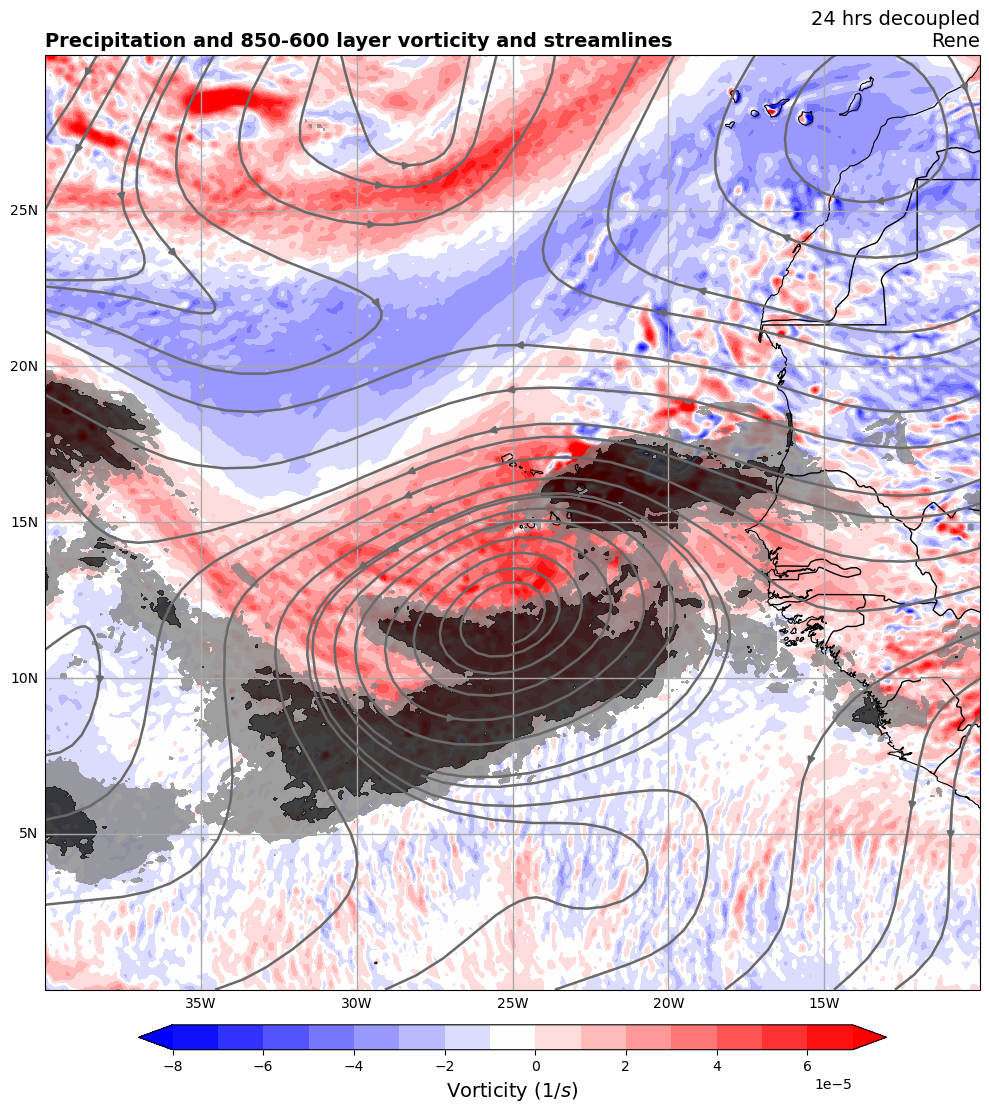

In [27]:
f = create_fig()